# Phase 5: Classifier Model Evaluation

This notebook loads the best trained EfficientNet-B0 classifier checkpoint, runs inference on the validation split, computes precision, recall, and per-class F1-scores, and generates detailed confusion matrices.

In [2]:
# Setup path and imports
from pathlib import Path
import sys
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import torchvision.models as models

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT.name != 'ai' and PROJECT_ROOT.parent != PROJECT_ROOT:
    if (PROJECT_ROOT / 'ai').exists():
        PROJECT_ROOT = PROJECT_ROOT / 'ai'
        break
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import utils

In [3]:
# Set device
device = utils.device.get_device()
print("Evaluating on accelerator:", device)

Evaluating on accelerator: cuda


In [4]:
# Build and load model weights
def build_classifier(num_classes):
    model = models.efficientnet_b0()
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)
    return model

model = build_classifier(utils.config.NUM_CLASSES).to(device)

if utils.config.BEST_MODEL_PATH.exists():
    checkpoint = torch.load(str(utils.config.BEST_MODEL_PATH), map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"✅ Successfully loaded best classifier weights from: {utils.config.BEST_MODEL_PATH}")
    print(f"Validator Checkpoint Validation Accuracy: {checkpoint['val_acc']:.4f}")
else:
    print("⚠️ Warning: Best weights checkpoint not found on disk. Running evaluation on mock random weights.")

✅ Successfully loaded best classifier weights from: O:\Hackthons\KrishiOS\ai\models\classifier\best_model.pth
Validator Checkpoint Validation Accuracy: 0.9966


In [5]:
# Setup validation loader
val_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(utils.config.IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_dataset = datasets.ImageFolder(root=str(utils.config.VAL_DIR), transform=val_transforms)
val_loader = DataLoader(
    val_dataset,
    batch_size=utils.config.BATCH_SIZE,
    shuffle=False,
    num_workers=utils.config.NUM_WORKERS
)

class_names = val_dataset.classes

In [6]:
# Collect predictions
model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

print(f"Collected predictions for {len(y_true)} validation samples.")

Collected predictions for 10861 validation samples.


In [7]:
# Compute and print evaluation metrics using shared utils
report, matrix = utils.metrics.generate_evaluation_report(y_true, y_pred, target_names=class_names)
print("========================================================================")
print("CLASSIFICATION REPORT")
print("========================================================================")
print(report)

weighted_f1 = utils.metrics.calculate_f1_score(y_true, y_pred, average='weighted')
print(f"Overall Weighted F1-Score: {weighted_f1:.4f}")

CLASSIFICATION REPORT
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.99      1.00      1.00       126
                                 Apple___Black_rot       1.00      0.99      1.00       125
                          Apple___Cedar_apple_rust       1.00      1.00      1.00        55
                                   Apple___healthy       0.99      1.00      1.00       329
                               Blueberry___healthy       1.00      1.00      1.00       300
          Cherry_(including_sour)___Powdery_mildew       1.00      0.99      0.99       210
                 Cherry_(including_sour)___healthy       0.99      0.99      0.99       170
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.95      0.98      0.97       103
                       Corn_(maize)___Common_rust_       1.00      1.00      1.00       239
               Corn_(maize)___Northern_Leaf_Blight       

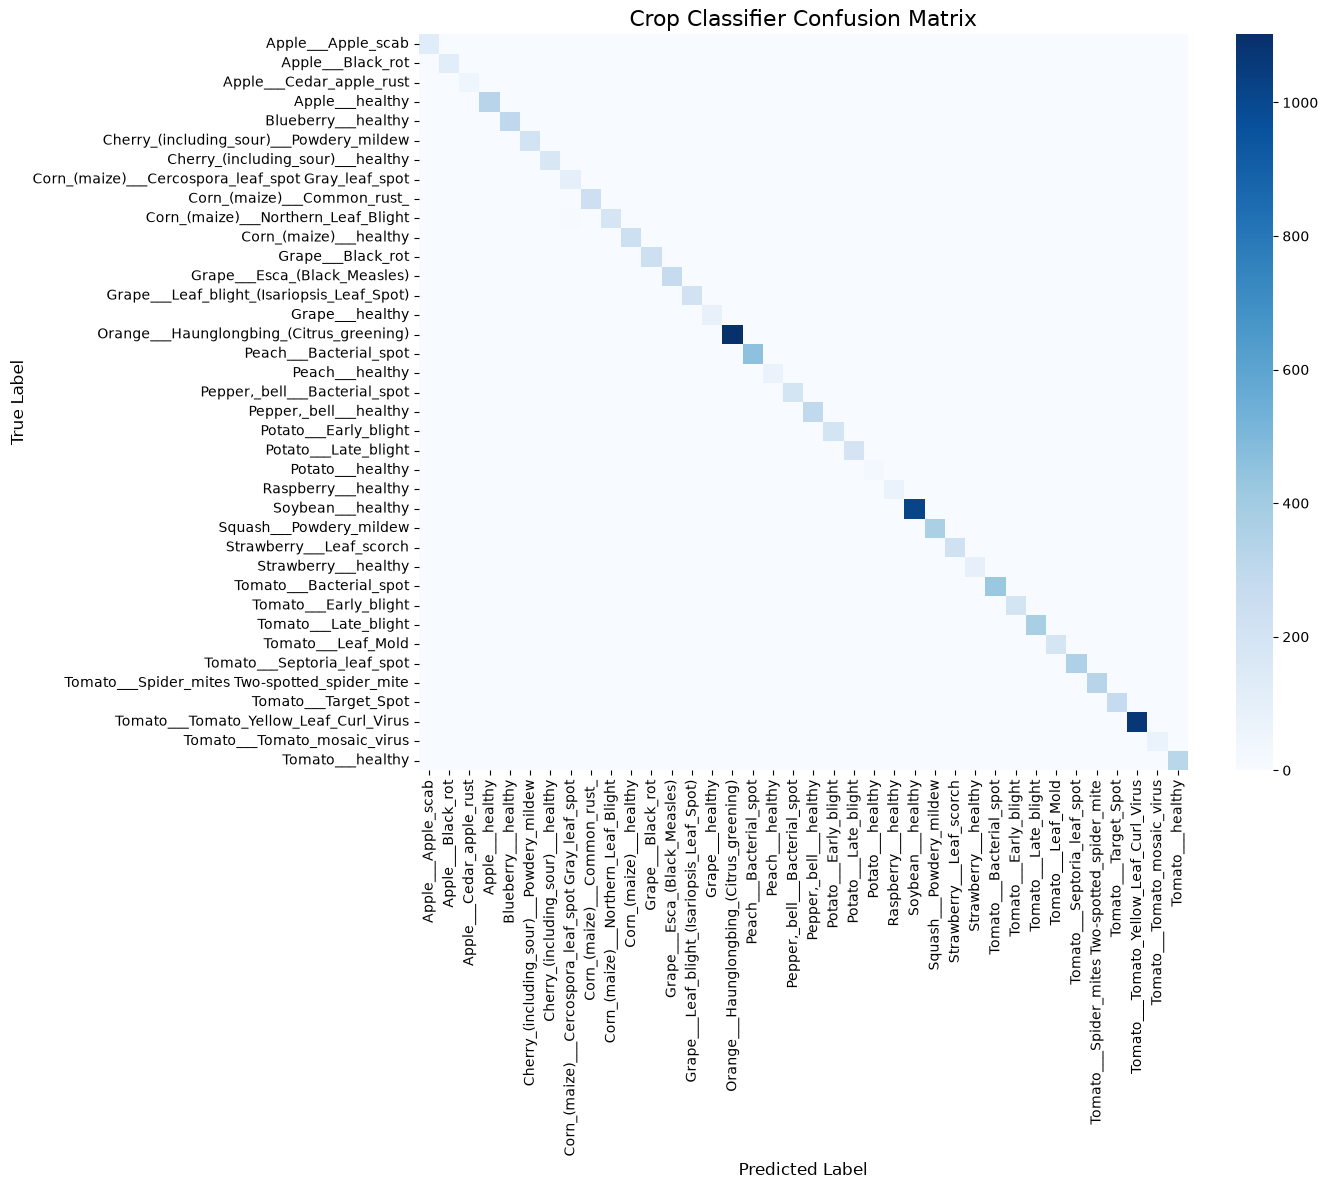

In [8]:
# Plot Seaborn confusion matrix heatmap
utils.visualization.plot_confusion_matrix(matrix, class_names=class_names, title="Crop Classifier Confusion Matrix")